Upload Dataset



In [ ]:
from google.colab import files
uploaded=files.upload()

Saving E-commerce Dataset.csv to E-commerce Dataset.csv


Install Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

%matplotlib inline

Load dataset

In [ ]:
df = pd.read_csv('/content/E-commerce Dataset.csv')

df.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


Dataset Overview

In [ ]:
print("Rows, Columns:", df.shape)

df.info()

Rows, Columns: (51290, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Order_Date           51290 non-null  object 
 1   Time                 51290 non-null  object 
 2   Aging                51289 non-null  float64
 3   Customer_Id          51290 non-null  int64  
 4   Gender               51290 non-null  object 
 5   Device_Type          51290 non-null  object 
 6   Customer_Login_type  51290 non-null  object 
 7   Product_Category     51290 non-null  object 
 8   Product              51290 non-null  object 
 9   Sales                51289 non-null  float64
 10  Quantity             51288 non-null  float64
 11  Discount             51289 non-null  float64
 12  Profit               51290 non-null  float64
 13  Shipping_Cost        51289 non-null  float64
 14  Order_Priority       51288 non-null  object 
 15  Payment_m

Missing values check

In [ ]:
df.isnull().sum()

,0
Order_Date,0
Time,0
Aging,1
Customer_Id,0
Gender,0
Device_Type,0
Customer_Login_type,0
Product_Category,0
Product,0
Sales,1


Duplicate check

In [ ]:
df.duplicated().sum()

np.int64(0)

Descriptive statistics

In [ ]:
df.describe()

,Aging,Customer_Id,Sales,Quantity,Discount,Profit,Shipping_Cost
count,51289.000000,51290.000000,51289.000000,51288.000000,51289.000000,51290.000000,51289.000000
mean,5.255035,58155.758764,152.340872,2.502983,0.303821,70.407226,7.041557
std,2.959948,26032.215826,66.495419,1.511859,0.131027,48.729488,4.871745
min,1.000000,10000.000000,33.000000,1.000000,0.100000,0.500000,0.100000
25%,3.000000,35831.250000,85.000000,1.000000,0.200000,24.900000,2.500000
50%,5.000000,61018.000000,133.000000,2.000000,0.300000,59.900000,6.000000
75%,8.000000,80736.250000,218.000000,4.000000,0.400000,118.400000,11.800000
max,10.500000,99999.000000,250.000000,5.000000,0.500000,167.500000,16.800000


Understand columns

In [ ]:
df.columns

Index(['Order_Date', 'Time', 'Aging', 'Customer_Id', 'Gender', 'Device_Type',
       'Customer_Login_type', 'Product_Category', 'Product', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Order_Priority',
       'Payment_method'],
      dtype='object')

Create return columns

In [ ]:
df['Returned'] = (
    (df['Discount'] > 20) |
    (df['Aging'] > 7) |
    (df['Profit'] < 0)
).astype(int)

df[['Discount','Aging','Profit','Returned']].head()

,Discount,Aging,Profit,Returned
0,0.3,8.0,46.0,1
1,0.3,2.0,112.0,0
2,0.1,8.0,31.2,1
3,0.3,7.0,26.2,0
4,0.3,9.0,160.0,1


Calculate Return Rate



In [ ]:
total_orders = len(df)

returned_orders = df['Returned'].sum()

return_rate = (returned_orders / total_orders) * 100

print("Total Orders:", total_orders)
print("Returned Orders:", returned_orders)
print("Return Rate:", round(return_rate,2), "%")

Total Orders: 51290
Returned Orders: 14385
Return Rate: 28.05 %


Average Values

In [ ]:
print("Average Sales:", df['Sales'].mean())
print("Average Discount:", df['Discount'].mean())
print("Average Aging:", df['Aging'].mean())
print("Average Shipping Cost:", df['Shipping_Cost'].mean())

Average Sales: 152.34087231180175
Average Discount: 0.3038214821891633
Average Aging: 5.255035192731385
Average Shipping Cost: 7.041556669071341


Sales Distribution

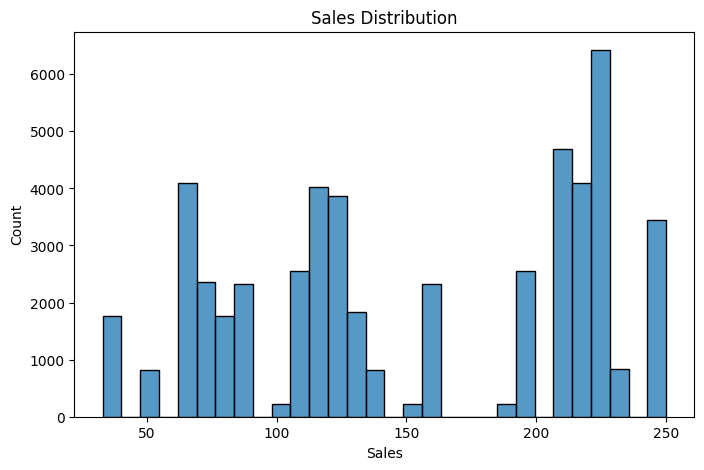

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=30)

plt.title("Sales Distribution")

plt.show()

Category vs Return Rate

In [ ]:
category_return = (
    df.groupby('Product_Category')
    ['Returned']
    .mean()*100
)

category_return

,Returned
Product_Category,
Auto & Accessories,29.606929
Electronic,28.026657
Fashion,26.421274
Home & Furniture,29.990931


Category Return Chart

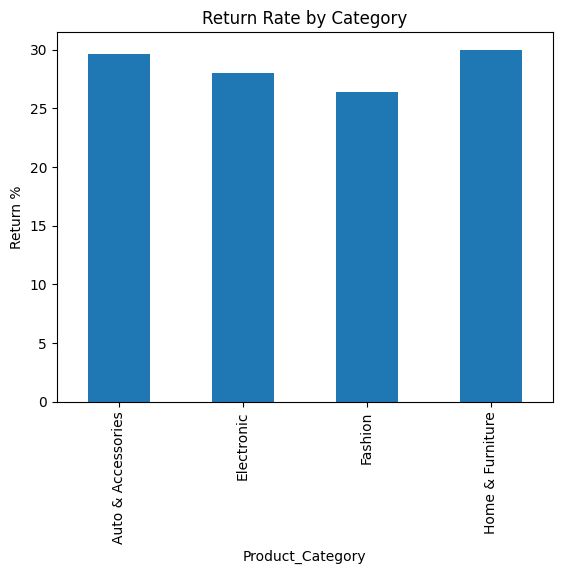

In [ ]:
category_return.plot(
    kind='bar'
)

plt.title("Return Rate by Category")

plt.ylabel("Return %")

plt.show()

Discount vs Return

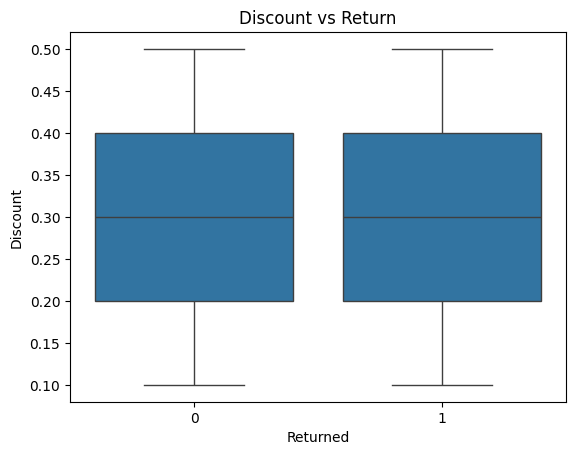

In [ ]:
sns.boxplot(
    x='Returned',
    y='Discount',
    data=df
)

plt.title("Discount vs Return")
plt.show()

Aging vs Return

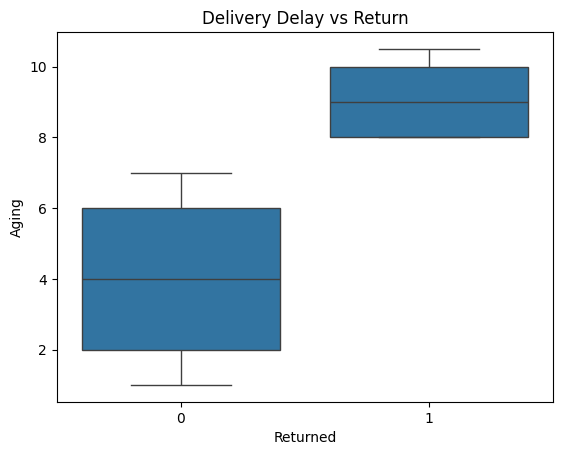

In [ ]:
sns.boxplot(
    x='Returned',
    y='Aging',
    data=df
)

plt.title("Delivery Delay vs Return")

plt.show()

Correlation Heatmap

In [ ]:
corr = df[
[
'Sales',
'Discount',
'Profit',
'Shipping_Cost',
'Aging',
'Returned'
]
].corr()

corr

,Sales,Discount,Profit,Shipping_Cost,Aging,Returned
Sales,1.000000,0.072583,0.916762,0.916500,-0.023091,-0.010250
Discount,0.072583,1.000000,-0.003204,-0.003495,-0.086324,-0.031791
Profit,0.916762,-0.003204,1.000000,0.999982,-0.018812,-0.010032
Shipping_Cost,0.916500,-0.003495,0.999982,1.000000,-0.018719,-0.009975
Aging,-0.023091,-0.086324,-0.018812,-0.018719,1.000000,0.790974
Returned,-0.010250,-0.031791,-0.010032,-0.009975,0.790974,1.000000


Heatmap visualization

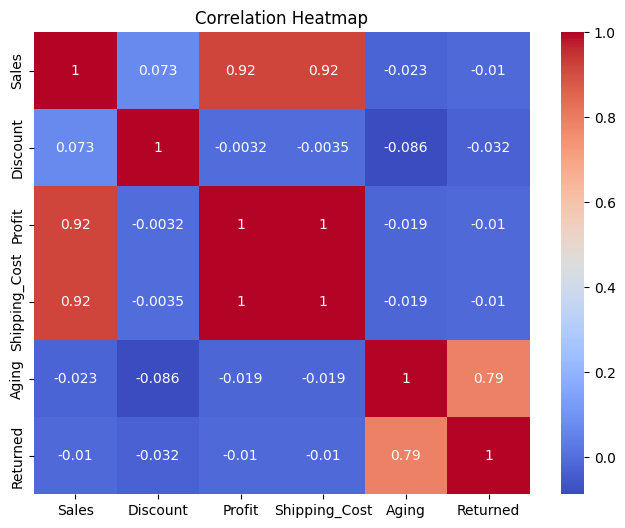

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Outlier Detection

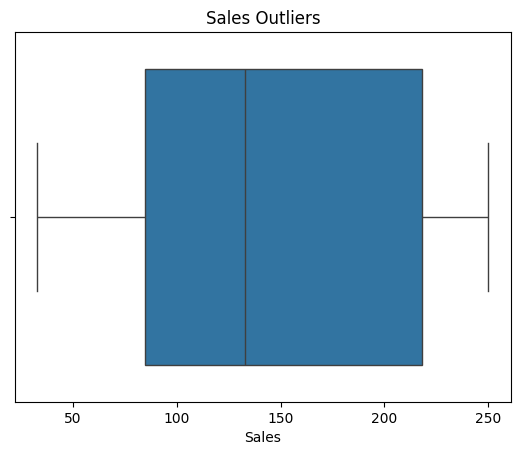

In [ ]:
sns.boxplot(
    x=df['Sales']
)

plt.title("Sales Outliers")

plt.show()

Hypothesis Testing

In [ ]:
returned = df[
    df['Returned']==1
]['Aging']

not_returned = df[
    df['Returned']==0
]['Aging']

t_stat,p_value = ttest_ind(
    returned,
    not_returned
)

print("T Statistic:",t_stat)
print("P Value:",p_value)

T Statistic: nan
P Value: nan


In [ ]:
if p_value < 0.05:
    print("Delivery delay significantly affects returns")
else:
    print("No significant impact")

No significant impact


Customer Segmentation

In [ ]:
customer_return = (
    df.groupby('Customer_Id')
    ['Returned']
    .sum()
    .sort_values(
        ascending=False
    )
)

customer_return.head(10)

,Returned
Customer_Id,
82069,3
96431,3
82256,3
82604,3
71200,3
92188,3
71127,3
99830,3
94392,3
